### Section A:

#### Section A1:

In [1]:
#1
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy
import sklearn

#2
df = pd.read_csv("SeoulBikeData_mod.csv")

#3
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4416 entries, 0 to 4415
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rented Bike Count          4416 non-null   int64  
 1   Hour                       4416 non-null   int64  
 2   Temperature(°C)            4416 non-null   float64
 3   Humidity(%)                4416 non-null   int64  
 4   Wind speed (m/s)           4416 non-null   float64
 5   Visibility (10m)           4416 non-null   int64  
 6   Dew point temperature(°C)  4416 non-null   float64
 7   Solar Radiation (MJ/m2)    4416 non-null   float64
 8   Rainfall(mm)               4416 non-null   float64
 9   Snowfall (cm)              4416 non-null   float64
 10  Month                      4416 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 379.6 KB


,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Month
count,4416.000000,4416.00000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000
mean,704.591259,11.50000,13.203986,59.257246,1.653193,1398.641304,4.723958,0.560181,0.139312,0.070879,5.956522
std,637.407244,6.92297,11.529724,20.162981,0.976361,621.560536,12.671445,0.860496,1.145271,0.437416,3.407262
min,0.000000,0.00000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,1.000000
25%,189.000000,5.75000,4.500000,44.000000,0.900000,853.000000,-3.500000,0.000000,0.000000,0.000000,3.000000
50%,542.000000,11.50000,14.300000,58.000000,1.500000,1621.000000,6.400000,0.010000,0.000000,0.000000,5.000000
75%,1047.000000,17.25000,22.200000,75.000000,2.200000,1999.000000,14.900000,0.910000,0.000000,0.000000,9.000000
max,3298.000000,23.00000,38.000000,98.000000,6.700000,2000.000000,26.800000,3.520000,35.000000,8.800000,11.000000


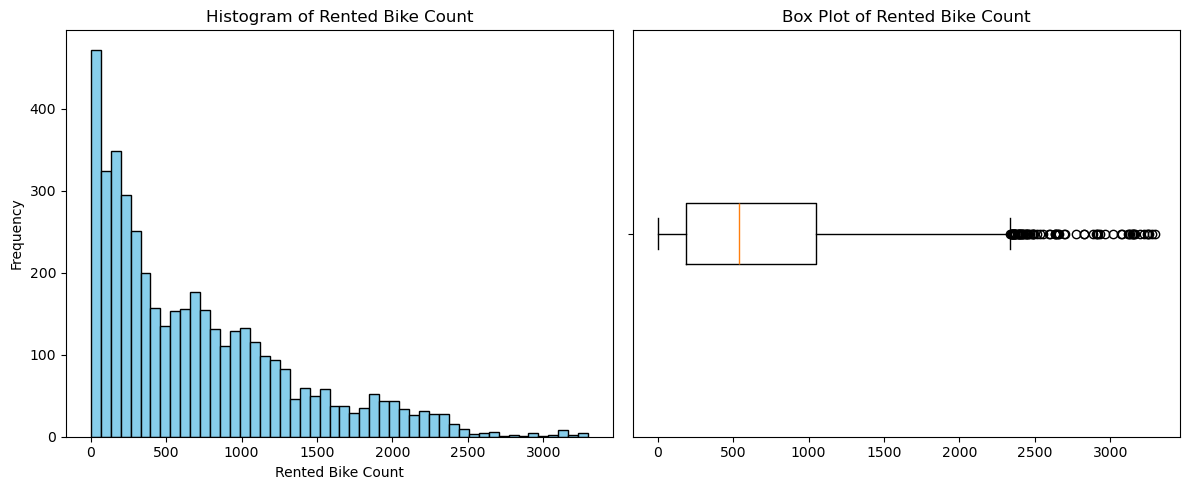

In [2]:
#4
RentedBikeCount = df["Rented Bike Count"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(RentedBikeCount, bins=50, color="skyblue", edgecolor="black")
ax1.set_xlabel("Rented Bike Count")
ax1.set_ylabel("Frequency")
ax1.set_title("Histogram of Rented Bike Count")

ax2.boxplot(RentedBikeCount, vert=False, tick_labels=[""])
ax2.set_title("Box Plot of Rented Bike Count")           

plt.tight_layout()
plt.show()

In [3]:
#5
X = df.drop(columns = ["Rented Bike Count"])
y = df["Rented Bike Count"]

#6
# in the research paper, 75% of the data is used for training and 25% is used for testing in the test-train split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size = 0.25, random_state = 100)

#7
model = sklearn.linear_model.LinearRegression()
model.fit(X_train,y_train)

#8
y_pred = model.predict(X_test)
resid = y_test - y_pred

#9 
R2 = sklearn.metrics.r2_score(y_test, y_pred)
MAE = sklearn.metrics.mean_absolute_error(y_test, y_pred)
MSE = sklearn.metrics.mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)

CV = (RMSE/np.mean(y_test))*100

print(f"R2 = {R2}")
print(f"MAE = {MAE}")
print(f"RMSE = {RMSE}")
print(f"CV = {CV}")

R2 = 0.4864602577706074
MAE = 330.20376773244544
RMSE = 447.88670296177287
CV = 65.38215352013525


**Seoul Bike Paper results:**  
R2 = 0.55  
MAE = 322.32  
RMSE = 427.71   
CV = 61.03  

note: whilst these results are very similar, there are discrepancies due to both the random sampling of rows in our training data set, and the fact that the data set used above contained half the data used in the Seoul Bike Paper, thus it is likely that their predictions were more accurate.

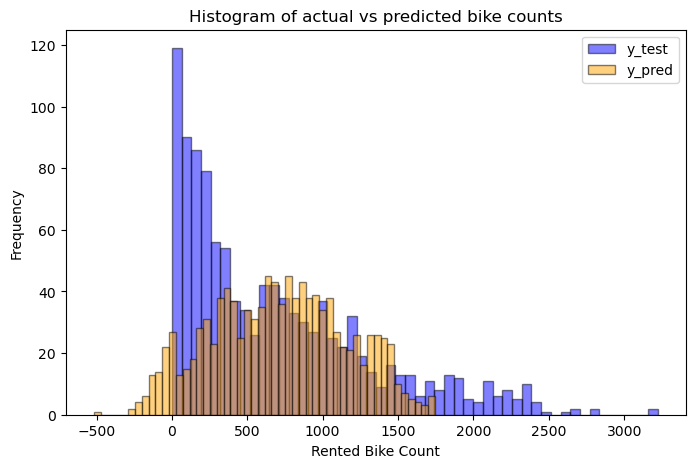

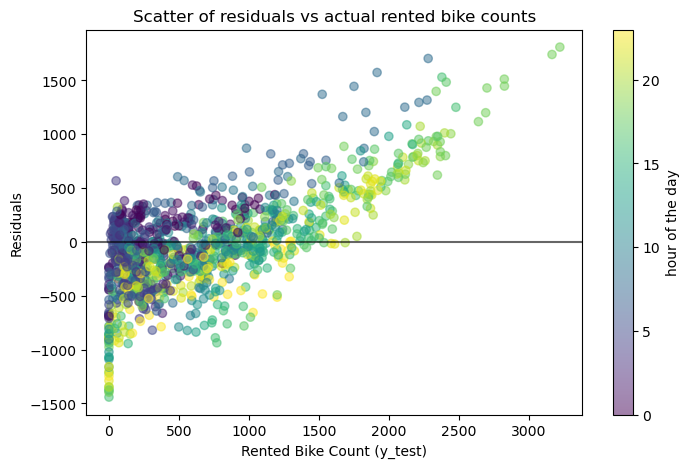

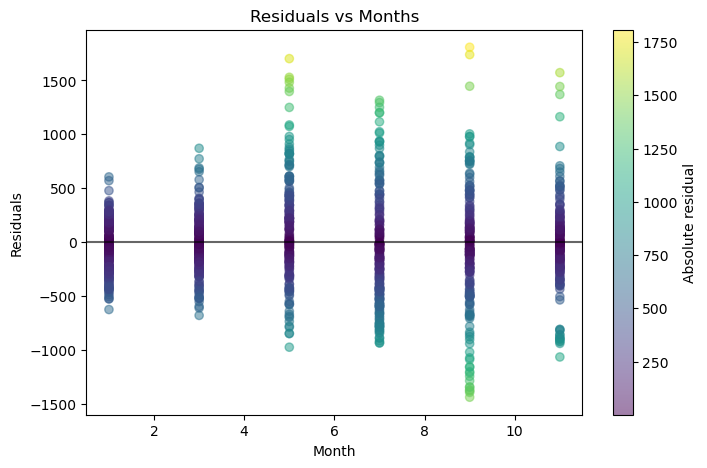

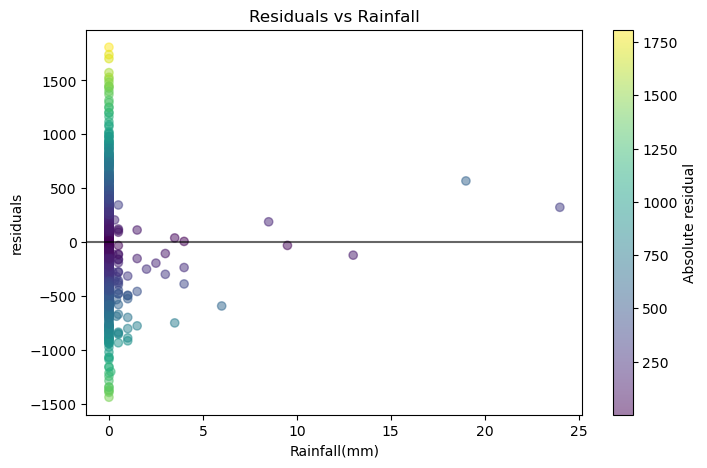

In [4]:
#10
# Histograms of y_test and y_pred
plt.figure(figsize=(8,5))
plt.hist(y_test, bins = 50, alpha = 0.5, label = "y_test", color= "blue", edgecolor="black")
plt.hist(y_pred, bins = 50, alpha = 0.5, label = "y_pred", color= "orange", edgecolor= "black")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")
plt.title("Histogram of actual vs predicted bike counts")
plt.legend()
plt.show()

# Scatter plot of resid as a function of y_test (corresponding to fig 9 of article)
plt.figure(figsize=(8,5))
scatter1 = plt.scatter(y_test, resid, c=X_test["Hour"], cmap= "viridis", alpha = 0.5)
plt.axhline(0, color = "black", alpha = 0.6)
plt.xlabel("Rented Bike Count (y_test)")
plt.ylabel("Residuals")
plt.title("Scatter of residuals vs actual rented bike counts")
plt.colorbar(label = "hour of the day")
plt.show()

# Scatter plot of resid vs month
plt.figure(figsize= (8,5))
scatter2 = plt.scatter(X_test["Month"], resid, c=np.abs(resid), cmap = "viridis", alpha = 0.5)
plt.colorbar(label = "Absolute residual")
plt.axhline(0, color = "black", alpha = 0.6)
plt.xlabel("Month")
plt.ylabel("Residuals")
plt.title("Residuals vs Months")
plt.show()

# Scatter plot of resid vs rainfall
plt.figure(figsize = (8,5))
scatter3 = plt.scatter(X_test["Rainfall(mm)"], resid, c = np.abs(resid), cmap = "viridis", alpha = 0.5)
plt.colorbar(label = "Absolute residual")
plt.axhline(0, color = "black", alpha = 0.6)
plt.xlabel("Rainfall(mm)")
plt.ylabel("residuals")
plt.title("Residuals vs Rainfall")
plt.show()

* The histogram shows us that the model is most accurate in the region of 500-1750 rented bike count however the model does an incredibly poor job at predicting rented bike count when it is between 0-500, as evident from the great difference between "y_test" and "y_pred" far below it (this perhaps indicates underfitting of the model). Furthermore the model predicts negative values for rented bike count, which is problematic since this of course does not match the real world data. We may consider that a straight line is too simple for the datas complexity.
* The first scatter plot tells a similar story as the histogram. We can see that the residuals are not well dispersed across the horizontal axis, which again indicates that the models accuracy is inconsistent depending on the volume of bikes being rented. Acknowledge that a superior model would depict random noise centred at zero, with roughly the same spread from left to right. One observation that we get from this scatter plot which is not evident in the histogram is that the colormap reveals that the model is more accurate at predicting during early hours i.e. closer to early morning results in smaller residuals - suggesting its "easier" for the model to predict a low number when the answer is zero than to predict a high number when the answer is massive. 
* Immediately we notice in the second scatter plot that the model is more accurate at predicting rented bike count in the months of January and March (there is no data for even months) and much less accurate on the months of april and september. Reasons for the latter may be due to this being the time of school holidays, thus schedules and daily activities are more chaotic and less routine for many households/
* The final scatter plot depicts a thick line at 0mm of Rainfall - it is worth explaining that this does not by itself suggest that the model is wildly inaccurate at predicting rented bike counts when there is no rain, rather it is simply a reflection of the fact that there are proportionately a lot more data points at 0mm representing days without rain. If we ignore this line, what is left behind suggests that the model is better at predicting the rented bike count when there is rain (comparing with scatter 1).

#### Section A2: 

**1. Derivation of the Cost Function, $J$**
We have three data points:
$(1,1), (2,4), (3,5)$.

The linear model is defined as $\hat{y}_i = m x_i + c$.

The loss for a given point is $L = (\hat{y}_i - y_i)^2 = (m x_i + c - y_i)^2$.

The Mean Squared Error (MSE) cost function $J$ is the mean of these losses:

$$J = \frac{1}{3} \sum_{i=1}^{3} (m x_i + c - y_i)^2$$

Expanding this for each of the three points:

For $x=1, y=1$: $(m(1) + c - 1)^2 = m^2 + c^2 + 1 + 2mc - 2m - 2c$

For $x=2, y=4$: $(m(2) + c - 4)^2 = 4m^2 + c^2 + 16 + 4mc - 16m - 8c$

For $x=3, y=5$: $(m(3) + c - 5)^2 = 9m^2 + c^2 + 25 + 6mc - 30m - 10c$

Summing expanded terms together:

* $m^2$ terms:
$1m^2 + 4m^2 + 9m^2 = 14m^2$
* $c^2$ terms:
$1c^2 + 1c^2 + 1c^2 = 3c^2$
* $mc$ terms:
$2mc + 4mc + 6mc = 12mc$
* $m$ terms:
$-2m - 16m - 30m = -48m$
* $c$ terms:
$-2c - 8c - 10c = -20c$
* Constants: $1 + 16 + 25 = 42$

Dividing entire sum by 3 gives the final cost function:
$$J = \frac{14m^2 + 12cm - 48m + 3c^2 - 20c + 42}{3}$$

**2. Partial Derivatives of the Cost Function**

To find the gradient for the descent steps, we find the partial derivatives of $J$ with respect to $m$ and $c$ using:

Partial derivative with respect to $m$:

$$\frac{\partial J}{\partial m} = \frac{1}{3}(28m + 12c - 48)$$

Partial derivative with respect to $c$:

$$\frac{\partial J}{\partial c} = \frac{1}{3}(12m + 6c - 20)$$

Initial parameters: m = 0.17361976716386174, c = -0.8865224596248154
Iteration 100 -> Cost = 0.24341556411791032
Iteration 200 -> Cost = 0.23531841991310407
Iteration 300 -> Cost = 0.2303148771383121
Iteration 400 -> Cost = 0.22722299153990613
Iteration 500 -> Cost = 0.22531239399254824
Iteration 600 -> Cost = 0.22413176072789773
Iteration 700 -> Cost = 0.223402201063422
Iteration 800 -> Cost = 0.2229513774927483
Iteration 900 -> Cost = 0.22267279590199487
Iteration 1000 -> Cost = 0.22250064939557035
the optimised parameters are: m = 1.9806200897404957, c = -0.622611575405206


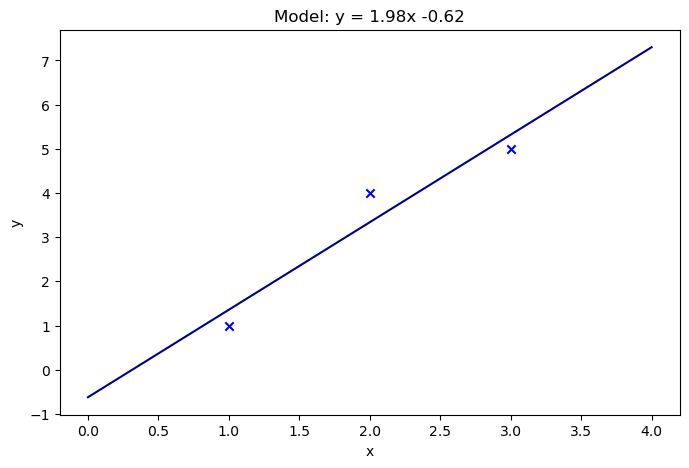

In [5]:
#3 
def J(m,c):
    return (14*m**2 + 12*c*m - 48*m + 3*c**2 -20*c +42)/3

def partials(m,c):
    # this of course calculates the gradient
    pm = (28*m + 12*c - 48)/3 
    pc = (12*m + 6*c - 20)/3
    return pm, pc
    

# setting the seed for reprocible results
np.random.seed(100)

def model1(alpha, num_iterations):
    #initialising m and c
    m = np.random.uniform(-2,2)
    c = np.random.uniform(-2,2)

    print(f"Initial parameters: m = {m}, c = {c}")

    for i in range(1, num_iterations+1):
        pm, pc = partials(m,c)

        #updating parameters
        m -= alpha * pm
        c -= alpha * pc

        #periodically printing cost
        if i % 100 == 0:
            print(f"Iteration {i} -> Cost = {J(m,c)}")

    return m,c

mOptimal, cOptimal = model1(alpha = 0.01, num_iterations = 1000)    
print(f"the optimised parameters are: m = {mOptimal}, c = {cOptimal}")

#4
#plotting
xpoints = np.array([1,2,3])
ypoints = np.array([1,4,5])

xarray = np.linspace(0,4,100)
yarray = mOptimal*xarray+cOptimal

plt.figure(figsize = (8,5))
plt.scatter(xpoints, ypoints, color = "blue", marker = "x")
plt.plot(xarray, yarray, color = "darkblue")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Model: y = {mOptimal:.2f}x {cOptimal:.2f}")
plt.show()

    

In [6]:
#5
# Exploring different learning rates and iteration numbers

print("\nLearning rate of 0.001")
model1(alpha=0.001, num_iterations=5000)

print("\nLearning rate of 0.05")
model1(alpha=0.05, num_iterations=1000)

print("\nLearning rate of 0.2")
model1(alpha=0.2, num_iterations=100)


Learning rate of 0.001
Initial parameters: m = -0.30192963700346764, c = 1.3791045292796147
Iteration 100 -> Cost = 2.101240422280952
Iteration 200 -> Cost = 1.1832595810325823
Iteration 300 -> Cost = 1.0490063749982828
Iteration 400 -> Cost = 1.000616434516066
Iteration 500 -> Cost = 0.9630448348679579
Iteration 600 -> Cost = 0.9281551933677031
Iteration 700 -> Cost = 0.8950021283444656
Iteration 800 -> Cost = 0.8634160834841182
Iteration 900 -> Cost = 0.8333140360322536
Iteration 1000 -> Cost = 0.8046253014367911
Iteration 1100 -> Cost = 0.7772834202559503
Iteration 1200 -> Cost = 0.7512251504975419
Iteration 1300 -> Cost = 0.7263902296327368
Iteration 1400 -> Cost = 0.7027212253811564
Iteration 1500 -> Cost = 0.6801634018369214
Iteration 1600 -> Cost = 0.6586645927751226
Iteration 1700 -> Cost = 0.6381750810022666
Iteration 1800 -> Cost = 0.6186474833812431
Iteration 1900 -> Cost = 0.6000366412549786
Iteration 2000 -> Cost = 0.5822995160145533
Iteration 2100 -> Cost = 0.56539508957

(-145353864.67011544, -63941416.07327105)

The learning rate can also be thought of as the "step size". If set too low (e.g. 0.001 in the above example), the model requires an enormous amount of iterations to converge, which is computationally inefficient, especially when the cost function plateaus or oscillates (bouncing back and forth across the minimum without ever landing on it), in which case no meaningful progress is made on each subsequent iteration. On the other hand, if it is set too high (e.g. 0.5), then the model becomes unstable and diverges rather than settling at a minimum - and if this is coupled with a large number of iterations, then the cost function may grow rapidly and eventually result in a numerical overflow error. Therefore, a good model requires a balance: a learning rate large enough to be computationally efficient, but not too large or else it may not converge to the minimum cost. Furthermore, the number of iterations must increase as the step size gets smaller, or else the minimum may not be reached.

#### Section A3: 

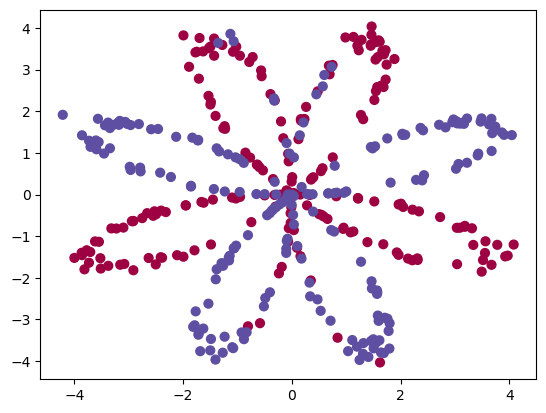

In [7]:
# Create the flower dataset

def load_flower_dataset():
    np.random.seed(1)

    m = 400 # number of examples
    N = int(m/2) # number of points per class
    D = 2 # dimensionality

    X = np.zeros((m,D)) # data matrix where each row is a single example
    y = np.zeros((m,1), dtype='uint8') # labels vector (0 for red, 1 for blue)
    a = 4 # maximum ray of the flower

    for j in range(2):
        ix = range(N*j,N*(j+1))
        t = np.linspace(j*3.12,(j+1)*3.12,N) + np.random.randn(N)*0.2 # theta
        r = a*np.sin(4*t) + np.random.randn(N)*0.2 # radius
        X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
        y[ix] = j

    X = X.T
    y = y.T

    return X, y

# Load the dataset:
X, y = load_flower_dataset()

# Visualize the dataset:
plt.scatter(X[0, :], X[1, :], c=y, s=40, cmap=plt.cm.Spectral);

Cost after iteration 0: 0.693769
Cost after iteration 1000: 0.673146
Cost after iteration 2000: 0.673146
Cost after iteration 3000: 0.673146
Cost after iteration 4000: 0.673146
Cost after iteration 5000: 0.673146
Cost after iteration 6000: 0.673146
Cost after iteration 7000: 0.673146
Cost after iteration 8000: 0.673146
Cost after iteration 9000: 0.673146


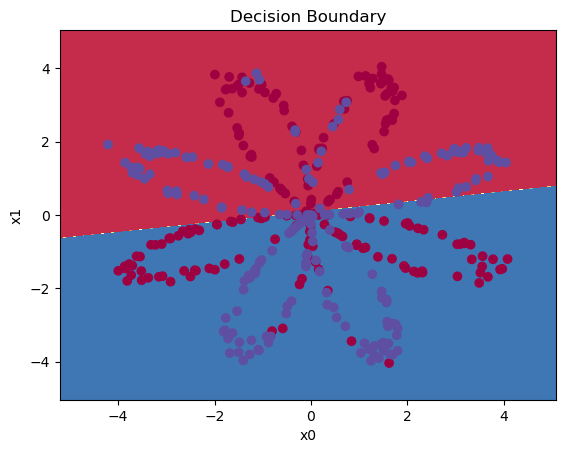

Accuracy of logistic regression: 47.00%


In [8]:
#helper functions

def initialize_parameters(n_X, n_y):
    W = np.random.randn(n_y, n_X) * 0.01
    b = np.zeros((n_y, 1))
    return {"W": W, "b" : b}

def sigmoid(z):
    return 1/(1+np.exp(-z))

def forward_propagation(X, parameters):
    W = parameters["W"]
    b = parameters["b"]
    z = np.dot(W, X) + b
    y_hat = sigmoid(z)
    return y_hat, z

def compute_cost(y_hat, y):
    m = y.shape[1]
    loss = -(y * np.log(y_hat) + (1-y) * np.log(1-y_hat))
    cost = float(np.sum(loss) / m)
    return cost

def backward_propagation(parameters, y_hat, X, y):
    m = y.shape[1]
    W = parameters["W"]
    dz = y_hat - y
    dW = np.dot(dz, X.T) / m 
    db = np.sum(dz, axis = 1, keepdims = True)/m
    return {"dW" : dW, "db" : db}

def update_parameters(parameters, grads, learning_rate = 1.2):
    W = copy.deepcopy(parameters["W"])
    b = copy.deepcopy(parameters["b"])
    W -= learning_rate * grads["dW"]
    b -= learning_rate * grads["db"]
    return {"W" : W, "b":b}

# logistic regression model

def model(X, y, num_iterations = 10000, print_cost = True):
    np.random.seed(3)
    n_X = X.shape[0]
    n_y = y.shape[0]
    parameters = initialize_parameters(n_X, n_y)

    for i in range(num_iterations):
        y_hat, z = forward_propagation(X, parameters)
        cost = compute_cost(y_hat, y)
        grads = backward_propagation(parameters, y_hat, X, y)
        parameters = update_parameters(parameters, grads, learning_rate=1.2)

        if print_cost and i % 1000 == 0:
            print(f"Cost after iteration {i}: {cost:.6f}")

    return parameters

def predict(learned_parameters, X):
    y_hat, z = forward_propagation(X, learned_parameters)
    predictions = (y_hat > 0.5).astype(int)
    return predictions

# Function to plot decision boundary

def plot_decision_boundary(learned_parameters, X, y):

    # Set min and max values and give it some padding
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z = predict(learned_parameters,np.c_[xx.ravel(), yy.ravel()].T)
    Z = Z.reshape(xx.shape)

    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x1')
    plt.xlabel('x0')
    plt.scatter(X[0, :], X[1, :], c=y, cmap=plt.cm.Spectral)
    plt.title("Decision Boundary")
    plt.show()

# Train the model
learned_parameters = model(X, y, num_iterations = 10000, print_cost=True)

# Plot the decision boundary
plot_decision_boundary(learned_parameters, X, y)

# evaluate the model
predictions = predict(learned_parameters, X)

accuracy = float(np.mean(predictions == y) * 100)
    
print(f'Accuracy of logistic regression: {accuracy:.2f}%')


#### Section A4: 

Cost after iteration 0: 0.693162
Cost after iteration 1000: 0.258625
Cost after iteration 2000: 0.239334
Cost after iteration 3000: 0.230802
Cost after iteration 4000: 0.225528
Cost after iteration 5000: 0.221845
Cost after iteration 6000: 0.219094
Cost after iteration 7000: 0.220598
Cost after iteration 8000: 0.219392
Cost after iteration 9000: 0.218480


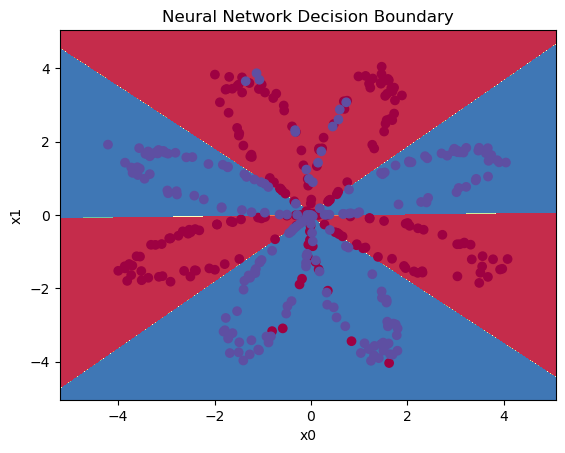

Accuracy of the neural network: 90.75% (the percentage of correctly labelled data points)


In [14]:
def initialize_parameters_nn(n_X, n_h, n_y):
    np.random.seed(3)
    W = np.random.randn(n_h, n_X) * 0.01   # hidden layer weights
    b = np.zeros((n_h, 1))                 # hidden layer biases
    T = np.random.randn(n_y, n_h) * 0.01   # output layer weights
    c = np.zeros((n_y, 1))                 # output layer biases
    return {"W" : W, "b" : b, "T" : T, "c" : c}

def forward_propagation_nn(X, parameters):
    W = parameters["W"]
    b = parameters["b"]
    T = parameters["T"]
    c = parameters["c"]

    z = np.dot(W, X) + b    # hidden layer linear transformation
    a = np.tanh(z)          # hidden layer activation
    v = np.dot(T, a) + c    # output layer linear transformation
    y_hat = sigmoid(v)      # output layer activation

    cache = {"z": z, "a": a, "v": v, "y_hat" : y_hat}
    return y_hat, cache

def backward_propagation_nn(parameters, cache, X, y):
    m = y.shape[1]
    T = parameters["T"]
    a = cache["a"]
    y_hat = cache["y_hat"]

    dv = y_hat - y
    dT = np.dot(dv, a.T) / m
    dc = np.sum(dv, axis=1, keepdims = True) / m
    dz = np.dot(T.T, dv) * (1-np.power(a, 2))
    dW = np.dot(dz, X.T) / m
    db = np.sum(dz, axis=1, keepdims=True) / m

    return {"dW" : dW, "db" : db, "dT" : dT, "dc" : dc}

def update_parameters_nn(parameters, grads, learning_rate = 1.2):
    W = copy.deepcopy(parameters["W"]) - learning_rate * grads["dW"]
    b = copy.deepcopy(parameters["b"]) - learning_rate * grads["db"]
    T = copy.deepcopy(parameters["T"]) - learning_rate * grads["dT"]
    c = copy.deepcopy(parameters["c"]) - learning_rate * grads["dc"]
    return {"W" : W, "b" : b, "T" : T, "c" : c}

def model_nn(X, y, n_h=4, num_iterations = 10000, print_cost = False):
    #initialise parameters
    np.random.seed(3)
    n_X = X.shape[0]
    n_y = y.shape[0]
    parameters = initialize_parameters_nn(n_X, n_h, n_y)

    #training loop
    for i in range(num_iterations):
        y_hat, cache = forward_propagation_nn(X, parameters)
        cost = compute_cost(y_hat, y)
        grads = backward_propagation_nn(parameters, cache, X, y)
        parameters = update_parameters_nn(parameters, grads, learning_rate=1.2)

        if print_cost and i%1000 == 0:
            print(f"Cost after iteration {i}: {cost:.6f}")

    return parameters

def predict_nn(learned_parameters, X):
    y_hat, _ = forward_propagation_nn(X, learned_parameters)
    predictions = (y_hat > 0.5).astype(int)
    return predictions

# function to plot the decision boundary for the neural net

def plot_decision_boundary_nn(learned_parameters, X, y):

    # Set min and max values and give it some padding
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z = predict_nn(learned_parameters,np.c_[xx.ravel(), yy.ravel()].T)
    Z = Z.reshape(xx.shape)

    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x1')
    plt.xlabel('x0')
    plt.scatter(X[0, :], X[1, :], c=y, cmap=plt.cm.Spectral)
    plt.title("Neural Network Decision Boundary")
    plt.show()

# training the model

learned_parameters_nn = model_nn(X, y, n_h=4, num_iterations=10000, print_cost=True)

# plotting the results

plot_decision_boundary_nn(learned_parameters_nn, X, y)

# evaluating the model

predictions_nn = predict_nn(learned_parameters_nn, X)
accuracy_nn = float(np.mean(predictions_nn == y) * 100)
print(f"Accuracy of the neural network: {accuracy_nn:.2f}% (the percentage of correctly labelled data points)")


A comparison between the logistic regression model and the neural network:

The logistic regression model achieved 47% accuracy when evaluated on the flower dataset. The primary reason for this poor performance is that the model can only learn linear decision boundaries, despite the fact the data set is extremely non-linear.

The neural network on the other hand, achieved 91% accuracy on the same dataset. This improvement was due to the fact that the model could learn non-linear patters such as those in the flower data set. The model can learn these non-linear functions due to the activation functions, since without them the extra layers are just a stack of linear transformations:
$ v = T(W \cdot X + b) + c$ (which is still still linear). Thus it is due to the hyperbolic tangent activation function that the model could learn these non-linear patterns.
